# Coursework Template

## Setup

**Dependencies and imports**

This can take a minute...

In [10]:
# !pip install swig
# !pip install rldurham

In [11]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disable CUDA (better on Colab/NCC: choose an environment without GPU)
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import rldurham as rld


In [12]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
print("device:", device)

device: cuda


**Reinforcement learning agent**

Replace this with your own agent. Also see the SAC implementationi below for a starting point.

In [13]:
class ReplayBuffer(object):
    def __init__(self, state_dim, action_dim, max_size=int(1e6), eta=0.996, c_min=5000):
        self.max_size = max_size
        self.ptr = 0
        self.size = 0

        self.state = np.zeros((max_size, state_dim))
        self.action = np.zeros((max_size, action_dim))
        self.reward = np.zeros((max_size, 1))
        self.next_state = np.zeros((max_size, state_dim))
        self.dead = np.zeros((max_size, 1))

        self.device = device

        # ERE 超参数
        self.eta = eta
        self.c_min = c_min

    def add(self, state, action, reward, next_state, dead):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.reward[self.ptr] = reward
        self.next_state[self.ptr] = next_state
        self.dead[self.ptr] = dead #0,0,0，...，1

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size, k=None, K=None):
        if k is not None and K is not None:
            # ERE 公式: N_k = max(N_total * eta^(k * 1000 / K), c_min)
            n_k = int(max(self.size * (self.eta ** (k * 1000 / K)), self.c_min))
            n_k = min(n_k, self.size)  # 确保范围不超过当前 buffer 大小

            # 计算采样区间的索引范围
            # 在循环队列中，最近的经验位于 [ptr - n_k, ptr)
            # 使用取模运算处理越界情况
            idx_range_end = self.ptr
            idx_range_start = self.ptr - n_k

            # 随机生成范围内索引并取模
            ind = np.random.randint(idx_range_start, idx_range_end, size=batch_size) % self.max_size
        else:
            # 默认全量均匀采样
            ind = np.random.randint(0, self.size, size=batch_size)

        return (
            torch.FloatTensor(self.state[ind]).to(self.device),
            torch.FloatTensor(self.action[ind]).to(self.device),
            torch.FloatTensor(self.reward[ind]).to(self.device),
            torch.FloatTensor(self.next_state[ind]).to(self.device),
            torch.FloatTensor(self.dead[ind]).to(self.device)
        )


In [14]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, net_width, maxaction):
        super(Actor, self).__init__()

        self.l1 = nn.Linear(state_dim, net_width)
        self.l2 = nn.Linear(net_width, net_width)
        self.l3 = nn.Linear(net_width, action_dim)

        self.maxaction = maxaction

    def forward(self, state):
        a = torch.tanh(self.l1(state))
        a = torch.tanh(self.l2(a))
        a = torch.tanh(self.l3(a)) * self.maxaction
        return a

In [15]:
class Q_Critic(nn.Module):
    def __init__(self, state_dim, action_dim, net_width, num_quantiles=25, num_critics=2, dropout_rate=0.01):
        super(Q_Critic, self).__init__()

        self.num_quantiles = num_quantiles
        self.num_critics = num_critics

        self.q_networks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(state_dim + action_dim, net_width),
                nn.LayerNorm(net_width),
                nn.ReLU(),
                nn.Dropout(p=dropout_rate),
                nn.Linear(net_width, net_width),
                nn.LayerNorm(net_width),
                nn.ReLU(),
                nn.Dropout(p=dropout_rate),
                nn.Linear(net_width, num_quantiles)
            ) for _ in range(num_critics)
        ])

    def forward(self, state, action):
        sa = torch.cat([state, action], 1)

        # 将每个 critic 的输出叠加，形状为: (batch_size, num_critics, num_quantiles)
        quantiles = torch.stack([net(sa) for net in self.q_networks], dim=1)
        return quantiles

In [16]:
class Agent(torch.nn.Module):
    def __init__(self,
        env_with_Dead,
        state_dim,
        action_dim,
        max_action,
        gamma=0.99,
        net_width=128,
        a_lr=1e-4,
        c_lr=1e-4,
        Q_batchsize=256,
        num_quantiles=25,
        num_critics=2,
        drop_quantiles=5,
        dropout_rate=0.01):
        super(Agent, self).__init__()

        self.actor = Actor(state_dim, action_dim, net_width, max_action).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=a_lr)
        self.actor_target = copy.deepcopy(self.actor)

        self.q_critic = Q_Critic(state_dim, action_dim, net_width, num_quantiles, num_critics, dropout_rate).to(device)
        self.q_critic_optimizer = torch.optim.Adam(self.q_critic.parameters(), lr=c_lr)
        self.q_critic_target = copy.deepcopy(self.q_critic)

        self.env_with_Dead = env_with_Dead
        self.action_dim = action_dim
        self.max_action = max_action
        self.gamma = gamma
        self.policy_noise = 0.2 * max_action
        self.noise_clip = 0.5 * max_action
        self.tau = 0.005
        self.Q_batchsize = Q_batchsize
        self.delay_counter = -1
        self.delay_freq = 1
        # TQC 超参数
        self.num_quantiles = num_quantiles
        self.num_critics = num_critics
        self.drop_quantiles = drop_quantiles
        self.dropout_rate = dropout_rate

    def sample_action(self, s):
        # return torch.rand(self.act_dim) * 2 - 1 # unifrom random in [-1, 1]
        with torch.no_grad():
            state = torch.FloatTensor(s.reshape(1, -1)).to(device)
            a = self.actor(state)
        return a.cpu().numpy().flatten()

    def train(self, replay_buffer, k=None, K=None):
        self.delay_counter += 1

        with torch.no_grad():
            s, a, r, s_prime, dead_mask = replay_buffer.sample(self.Q_batchsize, k=k, K=K)
            noise = (torch.randn_like(a) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
            smoothed_target_a = (
                    self.actor_target(s_prime) + noise  # Noisy on target action
            ).clamp(-self.max_action, self.max_action)

        # Compute the target Q value
        z_target = self.q_critic_target(s_prime, smoothed_target_a)
        z_target_flatten = z_target.view(self.Q_batchsize, -1)
        sorted_z_target, _ = torch.sort(z_target_flatten, dim=1)
        kept_z_target = sorted_z_target[:, : -self.drop_quantiles]

        '''DEAD OR NOT'''
        if self.env_with_Dead:
            target_Q = r + (1 - dead_mask) * self.gamma * kept_z_target  # env with dead
        else:
            target_Q = r + self.gamma * kept_z_target  # env without dead

        # Get current Q estimates
        current_z = self.q_critic(s, a)

        # target_Q 形状扩展至 (batch, 1, 1, num_kept_quantiles)
        target_Q_ext = target_Q.unsqueeze(1).unsqueeze(1)
        # current_z 形状扩展至 (batch, num_critics, num_quantiles, 1)
        current_z_ext = current_z.unsqueeze(-1)
        # 差值计算
        td_error = target_Q_ext - current_z_ext
        # Huber Loss 计算
        kappa = 1.0  # Huber loss 的阈值
        abs_td_error = torch.abs(td_error)
        huber_loss = torch.where(abs_td_error <= kappa, 0.5 * abs_td_error ** 2, kappa * (abs_td_error - 0.5 * kappa))

        # 计算分位数权重Tau
        tau = torch.arange(1, self.num_quantiles + 1,
                           device=device).float() / self.num_quantiles - 0.5 / self.num_quantiles
        tau = tau.view(1, 1, self.num_quantiles, 1)

        # Quantile Loss公式: |tau - I(td_error < 0)| * huber_loss
        quantile_loss = torch.abs(tau - (td_error.detach() < 0).float()) * huber_loss

        # 在 kept_quantiles 维度求均值，在 quantiles 维度求和，在 critics 和 batch 维度求均值
        q_loss = quantile_loss.mean(dim=3).sum(dim=2).mean()

        # Optimize the q_critic
        self.q_critic_optimizer.zero_grad()
        q_loss.backward()
        self.q_critic_optimizer.step()

        # delay update actor
        if self.delay_counter == self.delay_freq:

            q_actor_quantiles = self.q_critic(s, self.actor(s))
            a_loss = -q_actor_quantiles.mean()

            self.actor_optimizer.zero_grad()
            a_loss.backward()
            self.actor_optimizer.step()

            # Update the frozen target models
            for param, target_param in zip(self.q_critic.parameters(), self.q_critic_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

            self.delay_counter = -1

    def save(self, filename):
        """保存模型参数到指定路径"""
        torch.save({
            'actor': self.actor.state_dict(),
            'actor_target': self.actor_target.state_dict(),
            'q_critic': self.q_critic.state_dict(),
            'q_critic_target': self.q_critic_target.state_dict(),
            'actor_optimizer': self.actor_optimizer.state_dict(),
            'q_critic_optimizer': self.q_critic_optimizer.state_dict(),
        }, filename)
        print(f"Model saved to {filename}")

    def load(self, filename):
        """从指定路径载入模型参数"""
        if os.path.exists(filename):
            checkpoint = torch.load(filename, map_location=device)
            self.actor.load_state_dict(checkpoint['actor'])
            self.actor_target.load_state_dict(checkpoint['actor_target'])
            self.q_critic.load_state_dict(checkpoint['q_critic'])
            self.q_critic_target.load_state_dict(checkpoint['q_critic_target'])
            self.actor_optimizer.load_state_dict(checkpoint['actor_optimizer'])
            self.q_critic_optimizer.load_state_dict(checkpoint['q_critic_optimizer'])
            print(f"Model loaded from {filename}")
        else:
            print(f"No checkpoint found at {filename}")


## Training

**Prepare the environment and wrap it to capture statistics, logs, and videos**

The device is: cuda (train on the cpu is recommended instead)
actions are continuous with 4 dimensions/#actions
observations are continuous with 24 dimensions/#observations
maximum timesteps is: 2000


C:\Users\Canic\PycharmProjects\DPL\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\Canic\PycharmProjects\reinforcementLearning\courseWork\normal_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


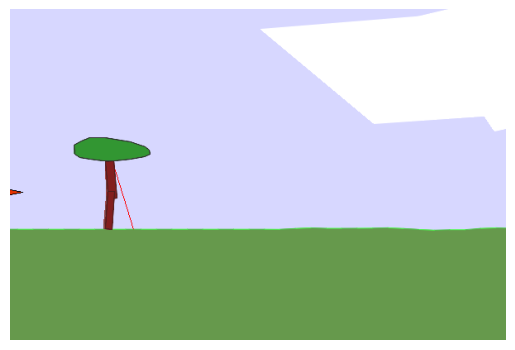

In [17]:
hard_mode = False

env = rld.make("rldurham/Walker", render_mode="rgb_array")
folder_prefix = "normal"
hard_mode_text = "-hardcore"
if hard_mode:
    env = rld.make("rldurham/Walker", render_mode="rgb_array", hardcore=True) # only attempt this when your agent has solved the non-hardcore version
    folder_prefix = "hard"


# get statistics, logs, and videos
env = rld.Recorder(
    env,
    smoothing=10,                       # track rolling averages (useful for plotting)
    video=True,                         # enable recording videos
    video_folder=f"{folder_prefix}_videos",              # folder for videos
    video_prefix=f"mwvy59-agent-video",  # prefix for videos (replace xxxx00 with your username)
    logs=True,                          # keep logs
)

# training on CPU recommended
# rld.check_device()

# environment info
rld.env_info(env, print_out=True)

# render start image (reset just to render image)
env.reset(seed=42)
rld.render(env)

**Collect episodes and train the agent**

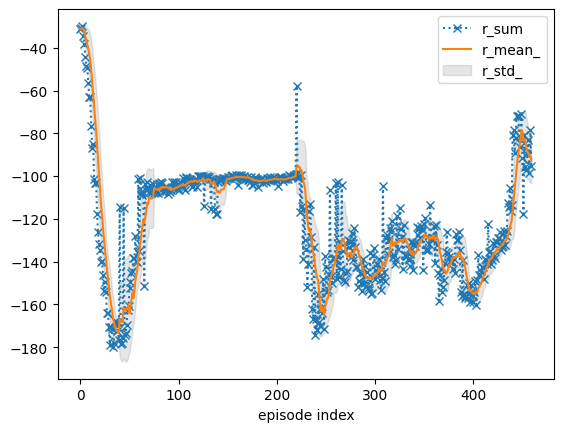

episode: 459 score: -95.14841667332517 step: 2000
episode: 460 score: -108.90967149821557 step: 2000
episode: 461 score: -103.99392251895321 step: 2000
episode: 462 score: -108.49741708047038 step: 2000
episode: 463 score: -107.47848552921106 step: 2000
episode: 464 score: -102.97208441418415 step: 2000
episode: 465 score: -106.30470279410683 step: 2000
episode: 466 score: -98.79079105166294 step: 2000
episode: 467 score: -98.60157086821417 step: 2000


In [ ]:
# in the submission please use seed_everything with seed 42 for verification
seed, observation, info = rld.seed_everything(42, env)

# 参数设计
env_with_Dead = True  # Whether the Env has dead state. True for Env like BipedalWalkerHardcore-v3, CartPole-v0. False for Env like Pendulum-v0
discrete_act, discrete_obs, act_dim, obs_dim = rld.env_info(env)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])
expl_noise = 0.3
print('  state_dim:', state_dim, '  action_dim:', action_dim, '  max_a:', max_action, '  min_a:', env.action_space.low[0])
kwargs = {
    "env_with_Dead": env_with_Dead,
    "state_dim": state_dim,
    "action_dim": action_dim,
    "max_action": max_action,
    "gamma": 0.99,
    "net_width": 256,
    "a_lr": 1e-4,
    "c_lr": 1e-4,
    "Q_batchsize": 256,
    "num_quantiles" : 25,
    "num_critics" : 5,
    "drop_quantiles" : 25,
    "dropout_rate" : 0.01,
}
max_episodes = 1000
save_score = 235
save_path = "result"
eta_0 = 0.996
cmin = 5000
# initialise agent, replay_buffer
agent = Agent(**kwargs)
replay_buffer = ReplayBuffer(state_dim, action_dim, max_size=int(1e6), eta=eta_0, c_min=cmin)

# track statistics for plotting
tracker = rld.InfoTracker()

# switch video recording off (only switch on every x episodes as this is slow)
env.video = False

# training procedure
for episode in range(max_episodes):

    # recording statistics and video can be switched on and off (video recording is slow!)
    env.info = True  # usually tracking every episode is fine
    env.video = episode % 100 == 0  # record videos every 100 episodes (set BEFORE calling reset!)

    # reset for new episode
    state, info = env.reset(seed=42)

    # run episode
    ep_r = 0
    steps = 0
    expl_noise = min(0.1, expl_noise * 0.999)
    done = False
    while not done:
        steps += 1

        # select the agent action
        action = (agent.sample_action(state) + np.random.normal(0, max_action * expl_noise, size=action_dim)
                ).clip(-max_action, max_action)

        # take action in the environment
        observation, reward, terminated, truncated, info = env.step(action)


        # remember
        if reward <= -100:
            replay_buffer.add(state, action, -100, observation, True)
        else:
            replay_buffer.add(state, action, reward, observation, False)

        # check whether done
        done = terminated or truncated
        state = observation
        ep_r += reward

        # train the agent after each step
        if replay_buffer.size > 2000:
            UTDratio = 5
            for i in range(UTDratio):
                # k 代表在该 episode 中当前的累计更新次数
                agent.train(replay_buffer)

    # track and plot statistics
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))
    print('episode:', episode, 'score:', ep_r, 'step:', steps)

    if int(ep_r) > save_score:
        agent.save(os.path.join(save_path, f"{episode}-{ep_r}.pth"))
        save_score = int(ep_r)
# don't forget to close environment (e.g. triggers last video save)
env.close()

# write log file (for coursework)
env.write_log(folder="logs", file=f"mwvy59-agent-log.txt")  # replace xxxx00 with your username